### 1. Setup and Imports


In [23]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Dict, Iterable, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

### 2. The Abstract Problem Interface


In [24]:
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass

### 3. The Node Class


In [25]:
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost

### 4. Helper Function


In [26]:
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []

    while node is not None:
        path.append(node.state)
        node = node.parent

    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []

    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent

    actions.reverse()
    return actions


def state_is_on_path(node: Node, state: Any) -> bool:
    """
    Return True if state already appears on the path from the root to node.

    This is useful for depth-limited search because DLS often uses path-cycle
    checking instead of a global reached set.
    """
    while node is not None:
        if node.state == state:
            return True
        node = node.parent

    return False


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Limit": result.limit,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier/stack": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])

### 5. Implementing the Grid Search Problem


In [27]:
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        # Return True if state is equal to the goal state.
        return state == self.goal

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        # Return a list of legal action names.
        legal_actions = []
        row, col = state
        
        for key, value in MOVES.items():
            dr, dc = value
            neighbor = (row + dr, col + dc)

            if self.in_bounds(neighbor) and self.is_free(neighbor):
                legal_actions.append(key)
        return legal_actions


    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        # Return the next state after applying action to state.
        row, col = state
        dr, dc = MOVES[action]

        return (row + dr, col + dc)

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # In this lab, each valid move has a cost of 1.

        return 1

### 5.1 Self-Check for GridProblem


In [28]:
test_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]

test_problem = GridProblem(test_grid, start=(0, 0), goal=(2, 2))

assert test_problem.initial_state() == (0, 0)
assert test_problem.is_goal((2, 2)) is True
assert test_problem.is_goal((0, 0)) is False
assert test_problem.actions((0, 0)) == ["RIGHT"]
assert test_problem.result((0, 0), "RIGHT") == (0, 1)
assert test_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 1

print("GridProblem self-check passed.")

GridProblem self-check passed.


### 6. Sample Drone Map


In [29]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

problem = GridProblem(sample_grid, start, goal)

### 7. Visualisation Helper


In [30]:
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()

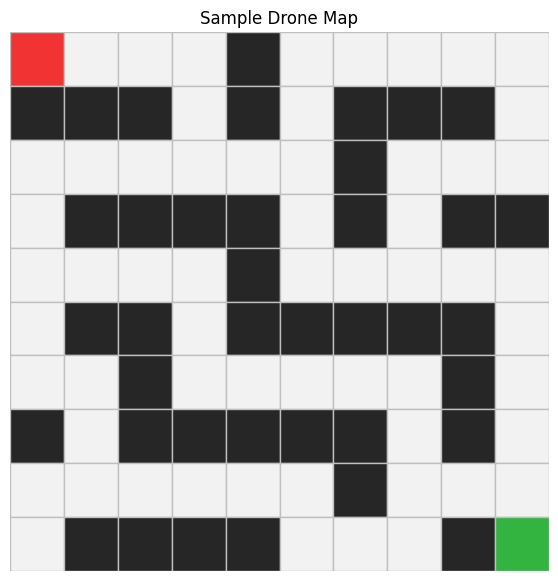

In [31]:
plot_path(sample_grid, start, goal, title="Sample Drone Map")

### 8. The Shared Expand Method


In [32]:
class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        s = node.state
        # for each legal action
        for action in problem.actions(s):
            s_prime = problem.result(s, action)
            cost = node.path_cost + problem.action_cost(s, action, s_prime)
            #    yield NODE(STATE=s_prime, PARENT=node, ACTION=action, PATH_COST=cost)
            yield Node(s_prime, node, action, cost)
       # raise NotImplementedError("Complete SearchAlgorithm.expand")

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass

### 9. Breadth-First Search(BFS)


In [33]:
class BreadthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        # Implement BFS graph search using a FIFO queue.
        algorithm = "BFS"
        nodes_expanded = 0
        max_frontier_size = 0
        reached_count = 0

        node = Node(problem.initial_state())
        # If the initial state is the goal, return success.
        if problem.is_goal(node.state):
            return SearchResult(
                algorithm=algorithm, 
                status= "success", 
                solution=node, 
                nodes_expanded= nodes_expanded, 
                max_frontier_size =max_frontier_size,
                reached_count=1)
        # Create a deque frontier and add the initial node.
        frontier = deque([node])
        # Create a reached set and add the initial state.
        reached = {problem.initial_state()}
        # While frontier is not empty:
        while frontier:
            node = frontier.popleft()
            nodes_expanded += 1
            # expand the node
            for child in self.expand(problem, node):
                #   if child is goal, return success.
                if problem.is_goal(child.state):
                    return SearchResult(
                        algorithm=algorithm, 
                        status="success",
                        solution= child,
                        nodes_expanded= nodes_expanded, 
                        max_frontier_size=max_frontier_size,
                        reached_count=len(reached)
                        )
                #   if child.state is not in reached:
                if child.state not in reached:

                    reached.add(child.state)
                    frontier.append(child)

        #    update max_frontier_size.
            max_frontier_size= max(max_frontier_size, len(frontier))
            reached_count = len(reached)
            
        #  Return failure if no solution is found
        return SearchResult(
            algorithm=algorithm,
            status="failure",
            solution=None,
            nodes_expanded=nodes_expanded, 
            max_frontier_size=max_frontier_size, 
            reached_count=reached_count)
    

### 10. Depth-First Search(DFS)


In [34]:
class DepthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        # Implement DFS graph search using a stack.
        algorithm = "DFS"
        nodes_expanded = 0
        max_frontier_size = 1
        reached_count=1

        node = Node(problem.initial_state())
        # If the initial state is the goal, return success.
        if problem.is_goal(node.state):
            return SearchResult(
                algorithm=algorithm,
                status="success",
                solution=node,
                nodes_expanded=nodes_expanded, 
                max_frontier_size= max_frontier_size,
                reached_count=reached_count)
    
        frontier = [node]
        reached = {node.state}
        
        while frontier:
            node = frontier.pop()
            nodes_expanded += 1
            children = list(self.expand(problem, node))
        #   expand the node.
            for child in reversed(children):
                s = child.state
                if problem.is_goal(s):
                    return SearchResult(
                        algorithm=algorithm,
                        status="success",
                        solution=child, 
                        nodes_expanded=nodes_expanded,
                        max_frontier_size=max_frontier_size,
                        reached_count = reached_count)
                
                if s not in reached:
                    reached.add(s)
                    frontier.append(child)
                
            reached_count = len(reached)
            max_frontier_size = max(max_frontier_size, len(frontier))
        # return failure if when the frontier is empty and no solution was found
        return SearchResult(
            algorithm=algorithm,
            status="failure",
            solution= None,
            nodes_expanded=nodes_expanded, 
            max_frontier_size=max_frontier_size,
            reached_count=reached_count)
    

### 11. Depth-Limited Search(DLS)

In [35]:
class DepthLimitedSearch(SearchAlgorithm):
    def search(self, problem: Problem, limit: int = 10) -> SearchResult:
        algorithm = "DLS"

        initial_node = Node(problem.initial_state())

        metrics = {
            "nodes_expanded": 0,
            "max_stack_size": 1,
        }

        solution, status = self._recursive_dls(
            problem=problem,
            node=initial_node,
            limit=limit,
            metrics=metrics,
            current_stack_size=1,
        )

        return SearchResult(
            algorithm=algorithm,
            status=status,
            solution=solution,
            nodes_expanded=metrics["nodes_expanded"],
            max_frontier_size=metrics["max_stack_size"],
            reached_count=0,
            limit=limit,
        )
    def _recursive_dls(
        self,
        problem: Problem,
        node: Node,
        limit: int,
        metrics: Dict[str, int],
        current_stack_size: int,
    ) -> Tuple[Optional[Node], str]:
        
        if problem.is_goal(node.state):
            return (node, "success")
        
        # if node.depth >= limit, return (None, "cutoff").
        elif node.depth >= limit:
            return (None, "cutoff")

        #  Otherwise:
        else:
        #   increment metrics["nodes_expanded"].
            metrics["nodes_expanded"] +=1
        #   set cutoff_occurred = False.
            cutoff_occurred = False
        
            for child in self.expand(problem,node):
        #      
                if state_is_on_path(node,child.state):
                    continue
        
                metrics["max_stack_size"]= max(metrics.get("max_stack_size",0), current_stack_size+1)
        #       recursively call _recursive_dls on the child.
                result, status = self._recursive_dls( problem, child, limit,metrics,current_stack_size+1)   
        #       if result is "success", return success immediately.
                if status == "success":
                    return (result, status)
        #       if result is "cutoff", set cutoff_occurred = True.
                elif status == "cutoff":
                    cutoff_occurred = True
        #       d. after all children:
            if cutoff_occurred:
                return (None, "cutoff")
            else:
                return(None, "failure")
       

### 12. Iterative Deepening Search

In [36]:
class IterativeDeepeningSearch(SearchAlgorithm):
    def search(self, problem: Problem, max_depth: int = 50) -> SearchResult:
        algorithm = "IDS"

        iteration_log = []
        # Accumulate total nodes expanded across all DLS iterations.
        total_nodes_expanded = 0
        #Track the maximum stack size seen in any DLS run.
        max_stack_size = 0
        dls = DepthLimitedSearch()
        for limit in range(0,max_depth+1):
            result= dls.search(problem, limit)
            status = result.status
            iteration_log.append((limit,status))
            total_nodes_expanded += result.nodes_expanded
            max_stack_size = max(max_stack_size, result.max_frontier_size)

            if status == "success":
                return SearchResult(algorithm=algorithm,
                                    status=status,
                                    solution=result.solution,
                                    nodes_expanded=total_nodes_expanded,
                                    max_frontier_size=max_stack_size,
                                    reached_count=result.reached_count,
                                    limit=limit,
                                    iterations=iteration_log)
            elif status == "failure":
                return SearchResult(algorithm=algorithm,
                                    status=status,
                                    solution=None,
                                    nodes_expanded=total_nodes_expanded,
                                    max_frontier_size=max_stack_size,
                                    reached_count=result.reached_count,
                                    limit=limit,
                                    iterations=iteration_log)
            
        return SearchResult(algorithm=algorithm,
                            status="cutoff",
                            solution=None,
                            nodes_expanded=total_nodes_expanded,
                            max_frontier_size=max_stack_size,
                            reached_count=result.reached_count,
                            limit=limit,
                            iterations=iteration_log)

       
        
       

### 13. Run the Algorithms on the Sample Map

In [37]:
bfs = BreadthFirstSearch()
dfs = DepthFirstSearch()
dls = DepthLimitedSearch()
ids = IterativeDeepeningSearch()

results = [
  bfs.search(problem),
  dfs.search(problem),
  dls.search(problem, limit=10),
  ids.search(problem, max_depth=30),
]

show_results(results)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,18.0,18.0,50,5,52
1,DFS,success,NaN,26.0,26.0,37,4,39
2,DLS,cutoff,10.0,NaN,NaN,16,11,0
3,IDS,success,18.0,18.0,18.0,356,19,0


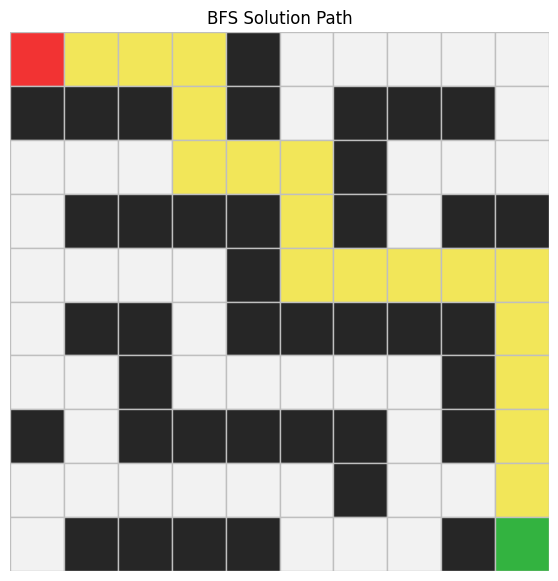

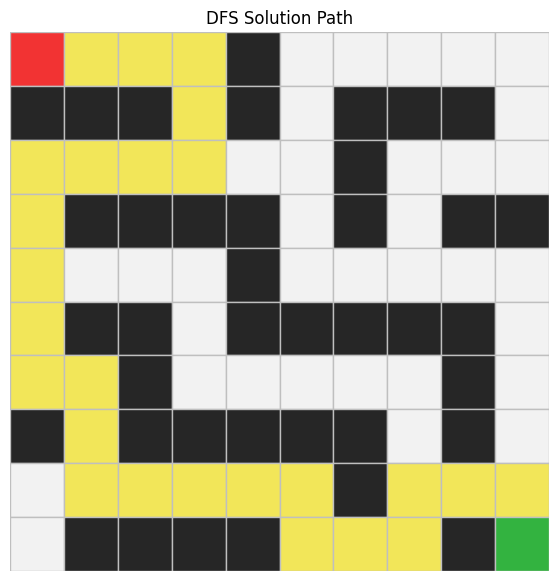

In [38]:
# Visualise solution paths.
# After your algorithms work, choose at least two algorithms and plot their paths.

bfs_result = results[0]
dfs_result = results[1]

plot_path(
    sample_grid,
    start,
    goal,
    path=bfs_result.path,
    title="BFS Solution Path",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=dfs_result.path,
    title="DFS Solution Path",
)

###

### 14. Create Your Own Maps

In [49]:

# TODO 10:
# Create your first custom map here.

custom_grid_1 = [[0,0,0,0,1,0,1,0],
                 [0,0,0,1,0,1,0,0],
                 [0,1,0,0,1,0,1,0],
                 [0,0,1,0,0,0,0,1],
                 [1,0,0,1,0,1,0,1],
                 [0,0,0,0,1,0,0,0],
                 [1,0,1,0,0,0,0,0],
                 [0,1,1,0,1,1,0,0]
                 ]

custom_start_1 = (0,0)
custom_goal_1 = (7,7)

# Example after completing:
custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)
custom_results_1 = [
     bfs.search(custom_problem_1),
     dfs.search(custom_problem_1),
     dls.search(custom_problem_1, limit=20),
     ids.search(custom_problem_1, max_depth=40),
    ]
show_results(custom_results_1)





,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,14,14,35,5,36
1,DFS,success,NaN,16,16,31,7,35
2,DLS,success,20.0,16,16,28,21,0
3,IDS,success,14.0,14,14,688,15,0


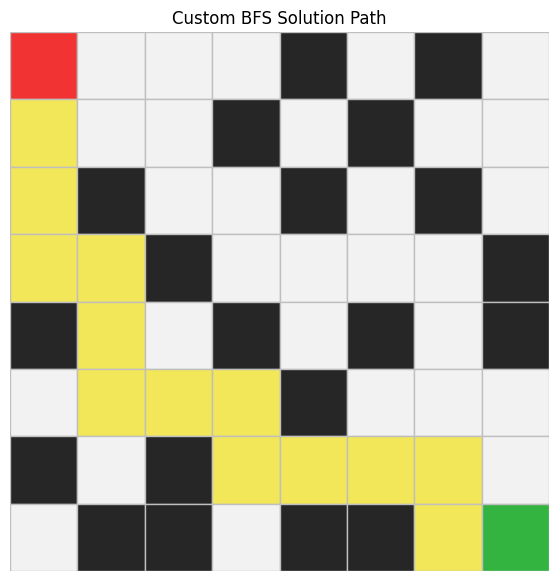

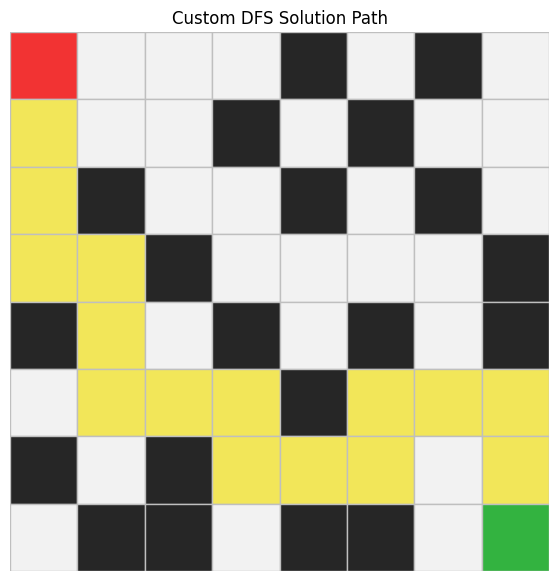

In [50]:

bfs_result = custom_results_1[0]
dfs_result = custom_results_1[1]

plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path=bfs_result.path,
    title="Custom BFS Solution Path",
)

plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path=dfs_result.path,
    title="Custom DFS Solution Path",
)

In [51]:
# TODO 11:
# Create your second custom map here.

custom_grid_2 = [
                [0,0,0,0,1,0,1,0,0,0,0,0,1,0,1,0],
                [0,0,0,1,0,1,0,0,0,0,0,1,0,1,0,0],
                [0,1,0,0,1,0,1,0,0,1,0,0,1,0,1,0],
                [0,0,1,0,0,1,1,0,0,1,0,0,1,0,1,0],
                [1,0,0,1,0,1,0,1,0,1,0,0,1,0,1,0],
                [0,1,1,0,0,0,0,0,0,1,1,0,0,0,0,0],
                [1,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0],
                [0,1,1,0,1,1,0,0,0,1,1,0,1,1,0,0],
                [0,0,1,0,0,1,1,0,0,1,0,0,1,0,1,0],
                [0,1,0,0,1,0,1,0,0,1,0,0,1,0,1,0],
                [0,0,1,0,0,1,1,0,0,1,0,0,1,0,1,0],
                [0,0,0,0,1,0,1,0,0,0,0,0,1,0,1,0],
                [1,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0],
                [0,1,1,0,1,1,0,0,0,1,1,0,1,1,0,0],
                [0,0,0,0,1,0,1,0,0,0,0,0,1,0,1,0],
                [0,0,1,0,0,1,1,0,0,1,0,0,1,0,1,0]
                 ]
    # Replace this with your own grid.

custom_start_2 = (0,0)
custom_goal_2 = (15,15)

# Example after completing:
custom_problem_2 = GridProblem(custom_grid_2, custom_start_2, custom_goal_2)
custom_results_2 = [
    bfs.search(custom_problem_2),
    dfs.search(custom_problem_2),
    dls.search(custom_problem_2, limit=20),

    ids.search(custom_problem_2, max_depth=40),
 ]
show_results(custom_results_2)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,30.0,30.0,143,13,148
1,DFS,success,NaN,50.0,50.0,115,33,135
2,DLS,cutoff,20.0,NaN,NaN,2270,21,0
3,IDS,success,30.0,30.0,30.0,368632,31,0


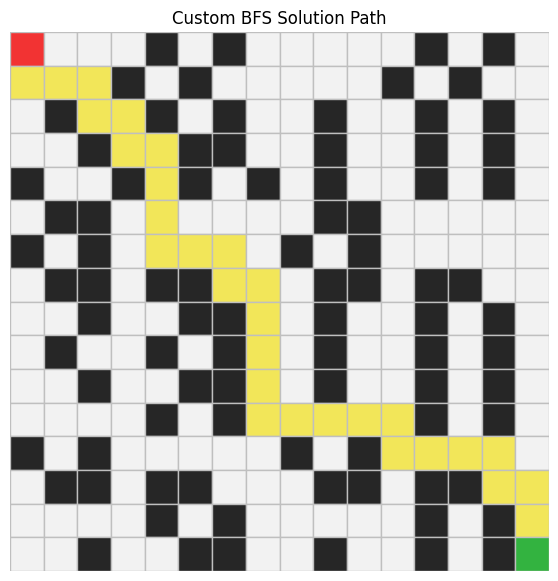

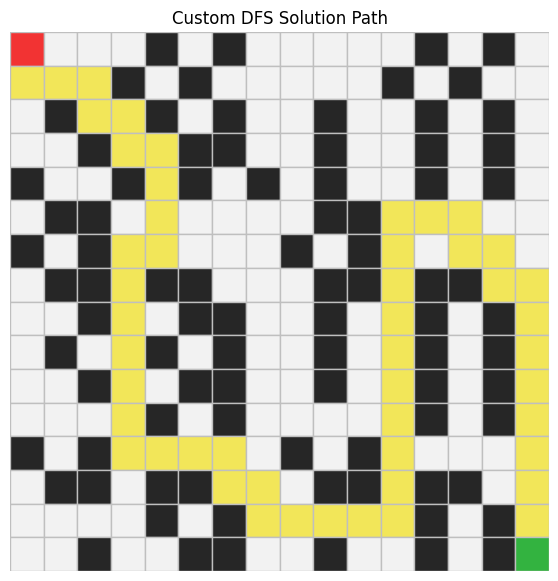

In [52]:

bfs_result = custom_results_2[0]
dfs_result = custom_results_2[1]

plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=bfs_result.path,
    title="Custom BFS Solution Path",
)

plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=dfs_result.path,
    title="Custom DFS Solution Path",
)

### 15. Reflection Questions

#### 15.1 Problem Formulation

1. In this lab, a state is the position of a cell. Represented by a tuple (x,y), x can be like the abscissa and y the ordinate in a 2d plane

2. An action is like the function that allows moving from one state to another

3. The result function provide the new state after an action is performed

4. It is useful to separate a problem definition from the search algorithm because it provides reusability of the algorithm. It means that you can use the same algorithm for solving different problems without having to rewrite a logic that fits each problem. Also, it can be useful for comparing how different algorithms solve the same tax and help in chosing what to optimize(time, memory, cost, etc)

#### 15.2 BFS

1. The BFS expands sequentially where the root node is expanded first, and the successors are expanded next. For efficiency purposes, a FIFO queue is faster as it give the correct order of nodes, allow the algorithm to expand the old nodes before new ones. 

2. BFS guarantees the shortest path on an unweighted grid because it generates the nodes at a certain depth after it has already generated the nodes at the previous depth. If one of them were a solution, it would have been found. Given its early goal test, it stops the first time it finds a solution, and that is the shortest solution possible.

3. The reached set keeps the nodes that have been reached already to avoid re-evaluating a node that has already been visited and falling into infinite loops. 

#### 15.3 DFS

1. DFS always expands the deepest node in the frontier list. A stack is the most suitable becomes it allows the algorithm to pop the last added node and goes deeper down a single branch rather than spreading like in bfs.

2. DFS does not guarantee to find the shortest path because it returns the first solution it finds, regardless of whether it is cheaper or shorter. When it starts follow a path it only stops when it hits a dead end, otherwise, it will keep going on that path without exploring other paths that might be more optimal. 

Under what conditions can DFS use less memory than BFS?

3. DFS relatively use less memory than BFS as it does not keep the reached set at all and the frontier is always smaller. BFS expands all the nodes at a depth and keeps their children in the frontier while DFS expands just one node. Therefore, DFS is better for finite state spaces that are long trees.

4. DFS performs badly in cyclic state spaces, it can get stuck in an infinite loop. It can expand a state many times through different paths when working in an acyclic state space. 

#### 15.4 DLS

What happens when the depth limit is too small?

1. When the limit is too small, it fails to reach a solution and makes the algorithm incomplete

2. "cutoff" is when the algorithm ends without finding a solution because it has reached the depth limit. The algorithm is incomplete in that case.

3. DLS imposes a depth limit that stops the algorithm from going deeper while DFS continues to go deeper until it hits a dead end. 

4. We use a path-cycle checking in DLS to prevent the algorithm from entering infinite loops and ensuring that the solution, if it exists, does not include visiting states many times. 

#### 15.5 IDS

1. IDS repeats DLS with increasing limits to solve the problem of what is a good limit, it uses the DLS to iterate and increase the limit when it hits a cutoff. It also combine the benefits of DFS and BFS by guaranting a solution when there is combined with the memory efficiency properties of the DFS. 

2. IDS dynamically increases its depth limit after it has finished exploring all the nodes before the depth limit. A small limit might make DLS miss the goal and return a cutoff but IDS will reach all the nodes if necessary and return a solution if there is one. 

3. IDS uses less memory than BFS because it uses the DFS logic to search and expand nodes. 

4. Repeatedly searching from the root results in re-generating the states near the top multiple times. 

#### 15.6  Real-World Drone Context


1. In a real drone application, one route will be safer and more practical than another if it navigates correctly to the goal location and succeed in avoiding the obstacles so that it can't be be damaged or lost in the way. Also, we can applied a cost function to it, depending on how much energy it will need for reaching the goal location. 

2. If all moves are equally costly, I will choose a BFS because it guarantees a solution when there is one and it will basically find the shortest route.

3. If I want to limit how deep the drone is allowed to search, I will use an IDS because it provides a solution that combines memory efficiency properties of the DFS and guarantee a solution as an BFS. 

4. The Grid model maps the problem as made of uniform states. It lacks actual realism and adaptability to the dynamic environment where the drone operates. For example, it might rain and the obstacles may increase or another event might happen and change entirely the situation.